<a href="https://colab.research.google.com/github/malith001/ME421_Mechanical_Systems_Lab-A04/blob/main/Control/E20438_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instructions

* Complete the activities in groups that were assigned for ME421 for the vibrations lab.

* Make a copy of this and save it in your group github group repository with your index number as the file name

* Do all your work, EXCLUSIVELY, in that saved notebook. Your github commits will serve as a refelection of your individual contributions.

#References

* https://github.com/mugalan/intrinsic-rigid-body-control-estimation/tree/main/rigid-body-control

#Task#1

## Twin rotor system dynamic model

Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com

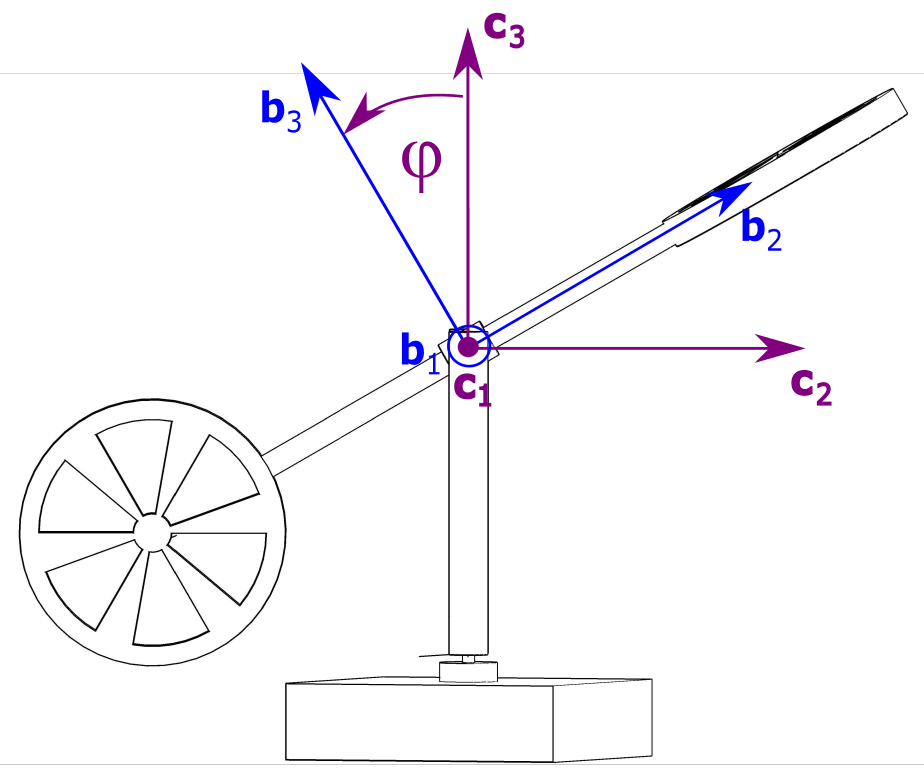

Show that the twin rotor system shown above can be modelled by

\begin{align}
\dot{R}&=\widehat{\omega}R,\\
\dot{\pi}&=\tau^e+\tau^u,
\end{align}
where
\begin{align}
\omega &=(\mathbb{I}^R)^{-1}\pi,
\end{align}
Here we have split the force and control moments into unmanipulatable and manipulatable (control) part. The manipulatable (control) part will be denoted by a superscript $u$ and takes the form

\begin{align*}
\tau^u &=R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix}
\end{align*}
and the constriant moment that prevents the rotation of the device about $\mathbb{b}_2$ axis is
\begin{align}
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
\end{align}
with $T_2$ given by
\begin{align}
T_2&=e_2^T \left(\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
\right)
\end{align}
where $\Omega = R^T\omega$.

# Task#2

Simulate and animate the motion of the system for various different realistic inputs. For examle a vertical axis spin and a horizontal axis swing up and down motion

#Task#3

Let $R_r(t)$ be a desired trajectory and $\omega_r(t)$ be such that $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$. In line with the system define the reference spatial angular momentum $\pi_r\triangleq R_r\mathbb{I}R_r^T\omega_r$

Define the configurarion error
\begin{align}
R_e&=R_rR^T.
\end{align}
Then the spatial angular velcity of the tracking error is defined by
\begin{align}
\widehat{\omega}_e&\triangleq \dot{R}_eR_e^T=\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T
\end{align}
and hence that
\begin{align}
\omega_e&=\omega_r-R_e\omega.
\end{align}
Define the angular momentum error as
\begin{align}
\pi_e\triangleq R\mathbb{I}R_r^T\omega_e=R\mathbb{I}R_r^T(\omega_r-R_e\omega)=R\mathbb{I}R_r^T\omega_r-R\mathbb{I}R^T\omega=R_e^T\pi_r-\pi.
\end{align}


Differentiating $\pi_e$ we have
\begin{align}
\dot{\pi}_e&=R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}=R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}=(R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}
\end{align}



Thus we have the error dynamics
\begin{align}
\dot{R}_e&=\widehat{\omega}_eR_e,\\
\dot{\pi}_e&=(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e
\end{align}

**Using these error dynamics derive a PID controller for the tracking problem and simulate its performance.**

#Task#4

 Experimentally verify the stability properties of the controller derived in Task#3 using the experimental setup available in the applied mechanics lab.

Here are few example our own implementations of this controller on UAVs

* https://youtu.be/6E9WDQNVSYA
* https://youtu.be/uUKxXImRMOA
* https://youtu.be/zq05N8m_9SA
* https://youtu.be/J5dThZGZN2g
* https://youtu.be/J5MMp6Be3tU
* https://youtu.be/6ZQgE1FI6Wc

### Euclidean PID Control vs Intrinsic Rigid Body PID Control

**Euclidean PID Control**

Euclidean PID control is the classical PID controller used for systems whose configuration space lies in the vector space $\mathbb{R}^n$. In such systems, the control error can be obtained by direct subtraction of the current state and the reference state.

The error is defined as

$$
e = x - x_r
$$

and the PID control law is

$$
u = -K_p e - K_d \dot{e} - K_I \int e\,dt
$$

Since $\mathbb{R}^n$ is a linear space, the subtraction operation is well defined and the controller can directly use the error vector.

Typical examples of systems where Euclidean PID is used include:
- Mass–spring–damper systems
- DC motor position control
- Temperature control
- Linear mechanical systems

However, Euclidean PID is **not suitable for rigid body orientation control** because rigid body rotations do not lie in a Euclidean space. Instead, orientations belong to the nonlinear manifold $SO(3)$. If Euler angles are used, problems such as **gimbal lock** and singularities may occur.

---

**Intrinsic Rigid Body PID Control**

Intrinsic rigid body PID control is a geometric extension of classical PID control designed for systems whose configuration space is a **Lie group**, such as the rotation group $SO(3)$.

Instead of subtracting angles, the orientation error is defined using rotation matrices:

$$
R_e = R_r R^T
$$

where  
$R$ = current orientation matrix  
$R_r$ = desired orientation matrix.

From this rotation error matrix, an error vector $e_R$ is extracted and used in the PID control law together with angular velocity and angular momentum errors.

Examples of systems that require intrinsic rigid body PID control include:
- Quadrotor drones
- Satellites and spacecraft
- Robotic manipulators
- Twin rotor laboratory systems

This intrinsic formulation avoids singularities, respects the geometry of rotation space, and allows stable control of rigid body attitude.

**2. Difference between $R_c = R^{-1}R_r$ and $R_e = R_rR^{-1}$. Why is $R_e$ used?**

Let $R$ denote the current orientation of the rigid body and $R_r$ the desired orientation.
The orientation error can be defined in two ways depending on the reference frame in which the error is expressed.

The **right–invariant error** is defined as

$$
R_e = R_r R^T
$$

while the **left–invariant error** is

$$
R_c = R^T R_r
$$

The difference between the two error definitions is the frame in which the error is expressed:

- $R_c = R^{-1}R_r$ is the **left–invariant error**, expressed in the **body frame**.
- $R_e = R_rR^{-1}$ is the **right–invariant error**, expressed in the **spatial (inertial) frame**.

In this work $R_e$ is used because the rigid body dynamics and angular momentum equations are formulated in the **spatial frame**, making the error dynamics and control law mathematically consistent and easier to derive.

**3. How is $e_R$ derived, and what is the role of $K$?**

Let $R$ be the current orientation of the rigid body and $R_r$ the desired orientation.  
The orientation error is defined using the rotation error matrix

$$
R_e = R_r R^T
$$

A Lyapunov error function on the rotation group is chosen as

$$
V = \frac{1}{2}\mathrm{trace}\big(K(I - R_e)\big)
$$

where $K$ is a positive definite gain matrix. Taking the derivative of this function with respect to the rotation gives the skew–symmetric matrix

$$
\hat{e}_R = \frac{1}{2}(R_e K - K R_e^T)
$$

The orientation error vector is then obtained using the vee operator

$$
e_R = (\hat{e}_R)^\vee
$$

where $e_R \in \mathbb{R}^3$.

The vector $e_R$ is the **attitude error vector** that represents the axis and magnitude of the rotational error between the current and desired orientations. It acts as the proportional error term in the attitude controller.

The matrix $K = \mathrm{diag}(K_1, K_2, K_3)$ is a **positive definite diagonal gain matrix** that determines the weighting of the orientation error along each axis. Physically, it behaves like a set of **virtual rotational stiffness gains**, controlling how strongly the system corrects orientation errors.

**4. Why is $(R\dot{\Pi}_r + \omega \times \pi_r)$ included in $\tau_u$?**

In the rigid body dynamics, the spatial angular momentum is

$$
\pi = R I R^T \omega
$$

and its dynamics are governed by

$$
\dot{\pi} = \tau_e + \tau_u
$$

To track a desired trajectory, the control input $\tau_u$ includes the term

$$
(R\dot{\Pi}_r + \omega \times \pi_r)
$$

which acts as a **feedforward compensation term**.

Here,

- $\pi_r = R_r I R_r^T \omega_r$ is the **desired spatial angular momentum** corresponding to the reference trajectory.
- $\Pi_r = I \Omega_r$ is the **desired body angular momentum**.
- $\dot{\Pi}_r$ is the **time derivative of the desired body angular momentum**, representing the required angular acceleration.
- $R$ is the current rotation matrix of the rigid body.
- $\omega$ is the spatial angular velocity.

The term $R\dot{\Pi}_r$ provides the torque required to produce the **desired angular acceleration**, while the term $\omega \times \pi_r$ compensates for the **gyroscopic coupling effects** in rigid body motion.

Including this feedforward term ensures that the controller accounts for the natural nonlinear dynamics of the rigid body, so that the PID feedback terms only need to correct the remaining tracking error.

**5. Significance of $T_2$, and how does it affect $T_u$?**

In the twin rotor system, the arm is mounted on a pivot that constrains rotation about the $b_2$ axis.  
Because of this mechanical constraint, a **reaction torque** appears at the joint.

This constraint torque is represented by

$$
\tau_e = R
\begin{bmatrix}
0 \\ T_2 \\ 0
\end{bmatrix}
$$

where

- $R$ is the rotation matrix describing the orientation of the body frame relative to the spatial frame.
- $T_2$ is the **constraint reaction torque** generated by the pivot joint.
- $\tau_e$ is the **external (unactuated) torque** acting on the system.

Physically, $T_2$ prevents the rotor arm from twisting about its own longitudinal axis ($b_2$ axis).  
Since the mechanical joint already enforces this constraint, the control motors do not need to generate torque along this axis.

Therefore the **middle component of the control torque** becomes zero:

$$
T_u =
\begin{bmatrix}
u_1 \cos\alpha - u_2 \cos\beta \\
0 \\
u_1 \sin\alpha - u_2 \sin\beta
\end{bmatrix}
$$

Thus $T_2$ represents the **passive reaction torque imposed by the mechanical constraint**, allowing the controller to act only on the two actuated axes.

**6. How is spatial velocity error $\omega_e$ related to reference and system velocities?**

Let

- $\omega$ be the **current spatial angular velocity** of the rigid body.
- $\omega_r$ be the **desired spatial angular velocity** of the reference trajectory.
- $R_e = R_r R^T$ be the **orientation error matrix**.

The spatial velocity error is defined as

$$
\omega_e = \omega_r - R_e \omega
$$

Here the term $R_e \omega$ rotates the current angular velocity into the **error frame** so that it can be directly compared with the reference velocity.

Thus $\omega_e$ represents the **difference between the desired and actual rotational velocities expressed in the same frame**.

Physically,

- If $\omega_e = 0$, the rigid body rotates at the correct angular speed.
- If $\omega_e \neq 0$, the controller must apply torque to correct the rotational speed error.

Therefore $\omega_e$ is the **kinematic velocity error used in the derivative term of the controller**.

**7. What specific property of $SO(3)$ is used to define configuration error?**

Rigid body orientations belong to the **special orthogonal group**

$$
SO(3)
$$

which is the set of all $3\times3$ rotation matrices satisfying

$$
R^T R = I, \quad \det(R) = 1
$$

A key property of $SO(3)$ is that it forms a **Lie group**, meaning it is **closed under matrix multiplication** and every element has an inverse.

Because of this property, the orientation error between two rotations $R$ and $R_r$ cannot be obtained by simple subtraction.  
Instead, the configuration error is defined using group multiplication:

$$
R_e = R_r R^T
$$

where

- $R$ is the current orientation,
- $R_r$ is the desired orientation,
- $R^T = R^{-1}$ is the inverse rotation.

This definition ensures that the error $R_e$ **remains on the manifold $SO(3)$**, which preserves the validity of the rotation representation.

**8. Differentiate between velocity error $\omega_e$ and momentum error $\pi_e$**

Two types of errors are used in rigid body control: **velocity error** and **angular momentum error**.

The velocity error is defined as

$$
\omega_e = \omega_r - R_e \omega
$$

where

- $\omega$ is the current angular velocity,
- $\omega_r$ is the desired angular velocity,
- $R_e$ is the orientation error matrix.

This error is **purely kinematic**, meaning it only measures the difference in rotational speed.

The momentum error is defined as

$$
\pi_e = R_e^T \pi_r - \pi
$$

where

- $\pi = R I R^T \omega$ is the **current spatial angular momentum**,
- $\pi_r$ is the **desired spatial angular momentum**,
- $I$ is the inertia tensor of the rigid body.

Unlike velocity error, $\pi_e$ is **dynamic**, because it depends on the inertia matrix $I$ and therefore includes the effect of mass distribution.

Physically,

- $\omega_e$ indicates **how fast the body is rotating incorrectly**.
- $\pi_e$ indicates **how much torque is required to correct the motion**.

Thus $\pi_e$ is directly related to the torque required for control.

**9. How does $\dot{R}_e$ relate to error velocity?**

The configuration error is defined as

$$
R_e = R_r R^T
$$

where $R$ is the current orientation and $R_r$ is the desired orientation.

Differentiating this expression leads to the **error kinematics equation**

$$
\dot{R}_e = \hat{\omega}_e R_e
$$

where

- $\omega_e$ is the **spatial angular velocity error**,
- $\hat{\omega}_e$ is the **skew-symmetric matrix representation** of $\omega_e$.

The operator $(\cdot)^\wedge$ converts a vector into a skew-symmetric matrix such that

$$
\hat{\omega}_e x = \omega_e \times x
$$

for any vector $x$.

This equation shows that the **rate of change of the orientation error** is governed by the angular velocity error.

Physically, if $\omega_e = 0$, then

$$
\dot{R}_e = 0
$$

which means the orientation error remains constant and the system is perfectly tracking the desired motion.

**10. Role of the integral term $e_{IR}$**

In intrinsic rigid body PID control, the integral error state is defined as

$$
\dot{e}_{IR} = e_R
$$

where

- $e_R \in \mathbb{R}^3$ is the **orientation error vector** derived from the rotation error matrix $R_e$.
- $e_{IR}$ is the **integral of the orientation error**.

Thus

$$
e_{IR}(t) = \int_0^t e_R(\tau)\,d\tau
$$

Physically, $e_{IR}$ acts as the **memory of the controller**, accumulating past orientation errors.  
It allows the controller to eliminate **steady-state errors** caused by constant disturbances such as model mismatch, asymmetric mass distribution, or persistent external forces.

In the control law, the term

$$
k_{IR} e_{IR}
$$

provides the **integral action** that drives the steady-state error to zero.

**11. Identify specific feedforward terms in $\tau_u$**

The spatial control torque $\tau_u$ contains feedforward terms

$$
R\dot{\Pi}_r + \omega \times \pi_r
$$

where

- $\Pi_r = I\Omega_r$ is the **desired body angular momentum**,
- $\dot{\Pi}_r$ is the **time derivative of the desired body angular momentum**,
- $\pi_r = R_r \Pi_r$ is the **desired spatial angular momentum**,
- $\omega$ is the **current spatial angular velocity**.

The term

$$
R\dot{\Pi}_r
$$

generates the torque required to produce the **desired angular acceleration**, while

$$
\omega \times \pi_r
$$

compensates for **gyroscopic coupling effects** in rigid body dynamics.

Sometimes the term $-\tau_e$ is also included to cancel **external constraint torques**.

These feedforward components ensure that the controller accounts for the **natural rigid body dynamics**, so the PID terms only correct tracking errors.

**12. What is the $b$-frame control law $T_u$, and how is it derived?**

The control torque is first computed in the **spatial frame** as $\tau_u$.  
To apply it to the physical actuators mounted on the body, it must be expressed in the **body frame**.

This transformation is performed using the rotation matrix $R$:

$$
T_u = R^T \tau_u
$$

Substituting the full spatial control law gives

$$
T_u =
\Big(\dot{\Pi}_r + \Omega \times R^T\pi_r \Big)
+ k_{PR}R^Te_R
+ k_{DR}\big(R^T\pi_r - I\Omega\big)
+ k_{IR}R^Te_{IR}
$$

where

- $\Omega$ is the **body angular velocity**,
- $I$ is the **inertia tensor**,
- $e_R$ is the **orientation error vector**,
- $e_{IR}$ is the **integral error state**.

Thus $T_u$ represents the **control torque expressed in the body frame**, which is directly applied by the actuators.

**13. In Python, how is $e_R$ extracted from $\hat{e}_R$?**

The orientation error matrix $\hat{e}_R$ is a **skew-symmetric matrix**

$$
\hat{e}_R =
\begin{bmatrix}
0 & -e_{R3} & e_{R2} \\
e_{R3} & 0 & -e_{R1} \\
-e_{R2} & e_{R1} & 0
\end{bmatrix}
$$

The vector $e_R = [e_{R1}, e_{R2}, e_{R3}]^T$ is obtained using the **vee operator**, which extracts the independent elements of the skew-symmetric matrix.

In Python this is implemented as

```python
e_R = np.array([e_R_hat[2,1], e_R_hat[0,2], e_R_hat[1,0]])

**14. How is the control input simplified when $\beta = \alpha$?**

The body-frame torque generated by the two motors is

$$
T_u =
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\beta \\
0 \\
u_1\sin\alpha - u_2\sin\beta
\end{bmatrix}
$$

where

- $u_1, u_2$ are the **motor thrust inputs**,
- $\alpha, \beta$ are the **tilt angles of the motors**.

If

$$
\beta = \alpha
$$

then the trigonometric terms become identical, and the expression simplifies to

$$
T_u =
\begin{bmatrix}
(u_1 - u_2)\cos\alpha \\
0 \\
(u_1 - u_2)\sin\alpha
\end{bmatrix}
$$

Thus the control torque depends only on the **difference in motor thrusts** $(u_1 - u_2)$.  
Physically, this means that pitch and yaw torques are generated by **imbalances between the two rotor forces**, simplifying the control structure.

**15. Method to determine thrust $u$ and angle $\alpha$ from a desired torque**

The body-frame control torque generated by the two rotors is

$$
T_u =
\begin{bmatrix}
u_1\cos\alpha - u_2\cos\alpha \\
0 \\
u_1\sin\alpha - u_2\sin\alpha
\end{bmatrix}
=
(u_1-u_2)
\begin{bmatrix}
\cos\alpha \\
0 \\
\sin\alpha
\end{bmatrix}
$$

where

- $u_1,u_2$ are the thrusts generated by the two rotors,
- $\alpha$ is the tilt angle of the rotors,
- $T_u$ is the control torque expressed in the body frame.

Let the desired body torque be

$$
T_u =
\begin{bmatrix}
\tau_x \\
0 \\
\tau_z
\end{bmatrix}
$$

Then the rotor tilt angle can be determined from the ratio of torque components:

$$
\tan\alpha = \frac{\tau_z}{\tau_x}
$$

Once $\alpha$ is known, the thrust difference $(u_1-u_2)$ can be obtained from

$$
u_1 - u_2 = \frac{\tau_x}{\cos\alpha}
$$

Thus the **desired torque is achieved by selecting the rotor tilt angle $\alpha$ and the thrust difference $(u_1-u_2)$**.

**16. What physical rotation is prevented by the constraint moment?**

In the twin rotor system the arm is mounted on a pivot that constrains rotation about one axis.

Let $\{b_1,b_2,b_3\}$ denote the body frame of the rotor arm.  
The constraint torque is represented by

$$
\tau_e = R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}
$$

where

- $R$ is the rotation matrix of the rigid body,
- $T_2$ is the constraint reaction torque,
- $\tau_e$ is the external constraint torque.

This torque prevents rotation about the **$b_2$ axis**, which is the **longitudinal axis of the rotor arm**.

Physically, this means the arm **cannot roll about its own length**.  
The mechanical pivot enforces this constraint, so the control system does not need to generate torque about this axis.

**17. In `referenceConfig`, how is $R_r$ generated?**

The desired orientation matrix $R_r$ represents the reference attitude trajectory.

It is constructed using sequential rotations about two axes:

$$
R_r = R_3(\theta_r) R_1(\phi_r)
$$

where

- $R_3(\theta_r)$ is a rotation about the **$z$-axis** (yaw rotation),
- $R_1(\phi_r)$ is a rotation about the **$x$-axis** (pitch rotation).

The rotation matrices are

$$
R_3(\theta_r)=
\begin{bmatrix}
\cos\theta_r & -\sin\theta_r & 0\\
\sin\theta_r & \cos\theta_r & 0\\
0 & 0 & 1
\end{bmatrix}
$$

$$
R_1(\phi_r)=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\phi_r & -\sin\phi_r\\
0 & \sin\phi_r & \cos\phi_r
\end{bmatrix}
$$

Thus $R_r$ represents a **desired yaw rotation followed by a pitch rotation**, defining the reference orientation that the twin rotor system should track.